In [51]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree 

In [53]:
np.random.seed(0) # The idea is that if we work with random numbers, then by using this function, we can reproduce the same results each time by setting the random number generator to 0.

In [59]:
cancer = pd.read_csv("breast_cancer.csv") # We download data
cancer

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,1


In [61]:
print(cancer.columns) # Check the column names

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')


In [14]:
X = cancer.drop("target", axis = 1) # We want to drop a column. To delete a row, we should use axis = 0
y = cancer["target"]
X




,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


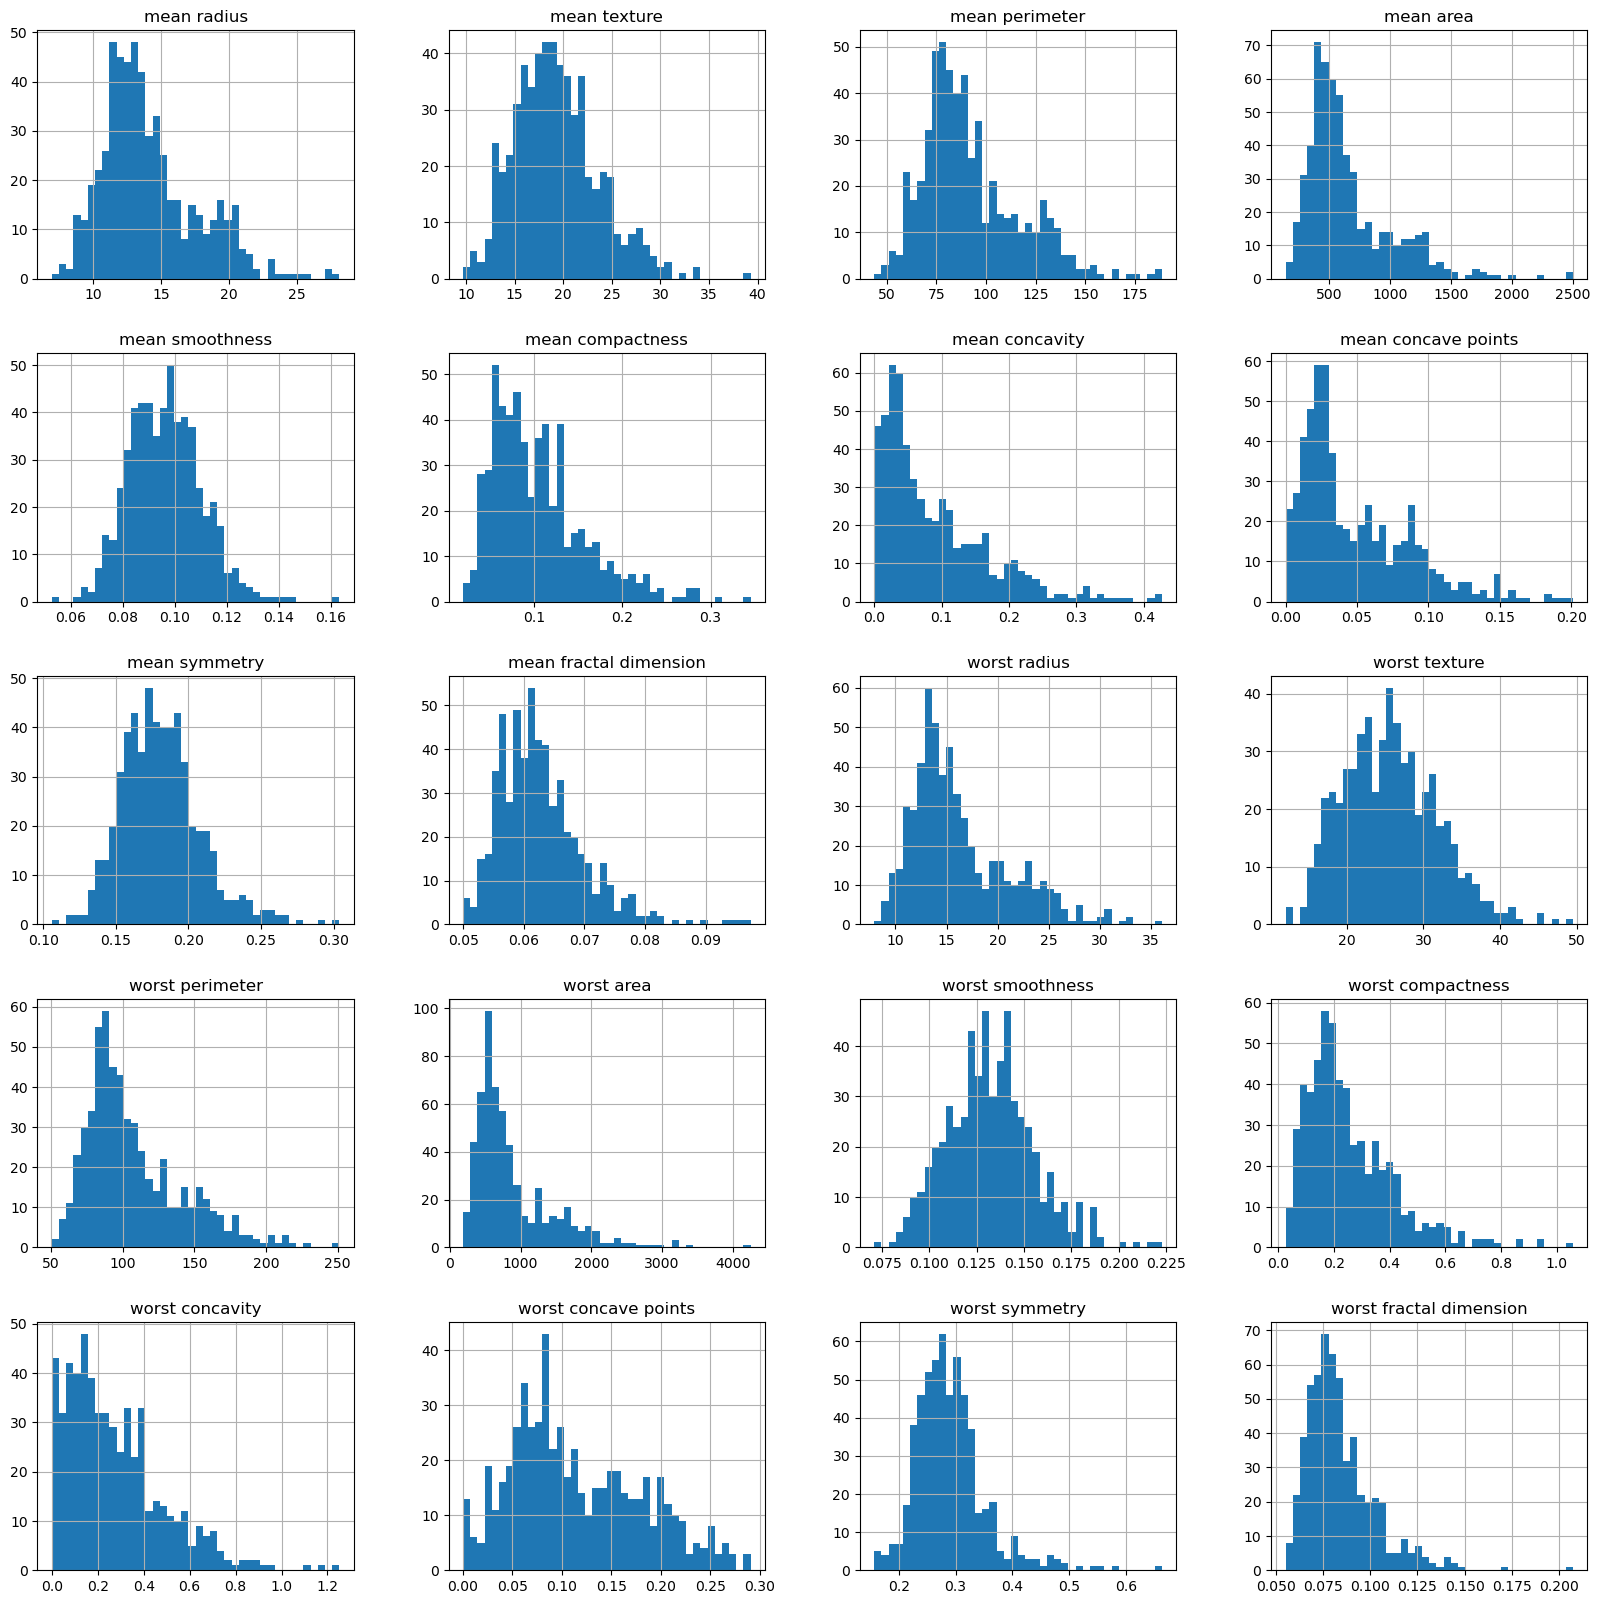

In [64]:
X.hist(bins = 40, figsize = (20,20))
plt.show()

In [66]:
nb_rows = int(X.shape[0]*0.2) # We keep 60% for training, 20% for validation, and 20% for testing. We use int() to get an integer instead of a float.

In [67]:
X_valid = X.sample(n = nb_rows, random_state = 0) # Randomly select rows from X for the validation set
valid_index = X_valid.index # We keep track of the indices of the validation rows
y_valid = y[valid_index] # We keep the corresponding indices for y

In [68]:
X_intermediate = X.drop(valid_index, axis = 0) #We drop all the rows already selected in X_valid
X_test = X_intermediate.sample(n=nb_rows, random_state = 0) # Randomly select rows from X for the test set
test_index = X_test.index # We keep track of the indices of the test rows
y_test = y[test_index] # We keep the corresponding indices for y


In [69]:
X_train = X_intermediate.drop(test_index, axis = 0) # We drop all the rows already selected in X_test
train_index = X_train.index # We keep track of the indices of the train rows
y_train = y[train_index] # We keep the corresponding indices for y


In [70]:
print('Total # of samples:', cancer.shape[0])
print('# of training samples:', X_train.shape[0])
print('# of validation samples:', X_valid.shape[0])
print("# of test samples:", X_test.shape[0])

Total # of samples: 569
# of training samples: 343
# of validation samples: 113
# of test samples: 113


In [71]:
model = DecisionTreeClassifier(random_state=0) # We create a decision tree. It classifies the data based on certain criteria. random_state=0 ensures that the results are reproducible.
model.fit(X_train,y_train) # Train the model on the training data so that it can learn to predict y_train from X_train.

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

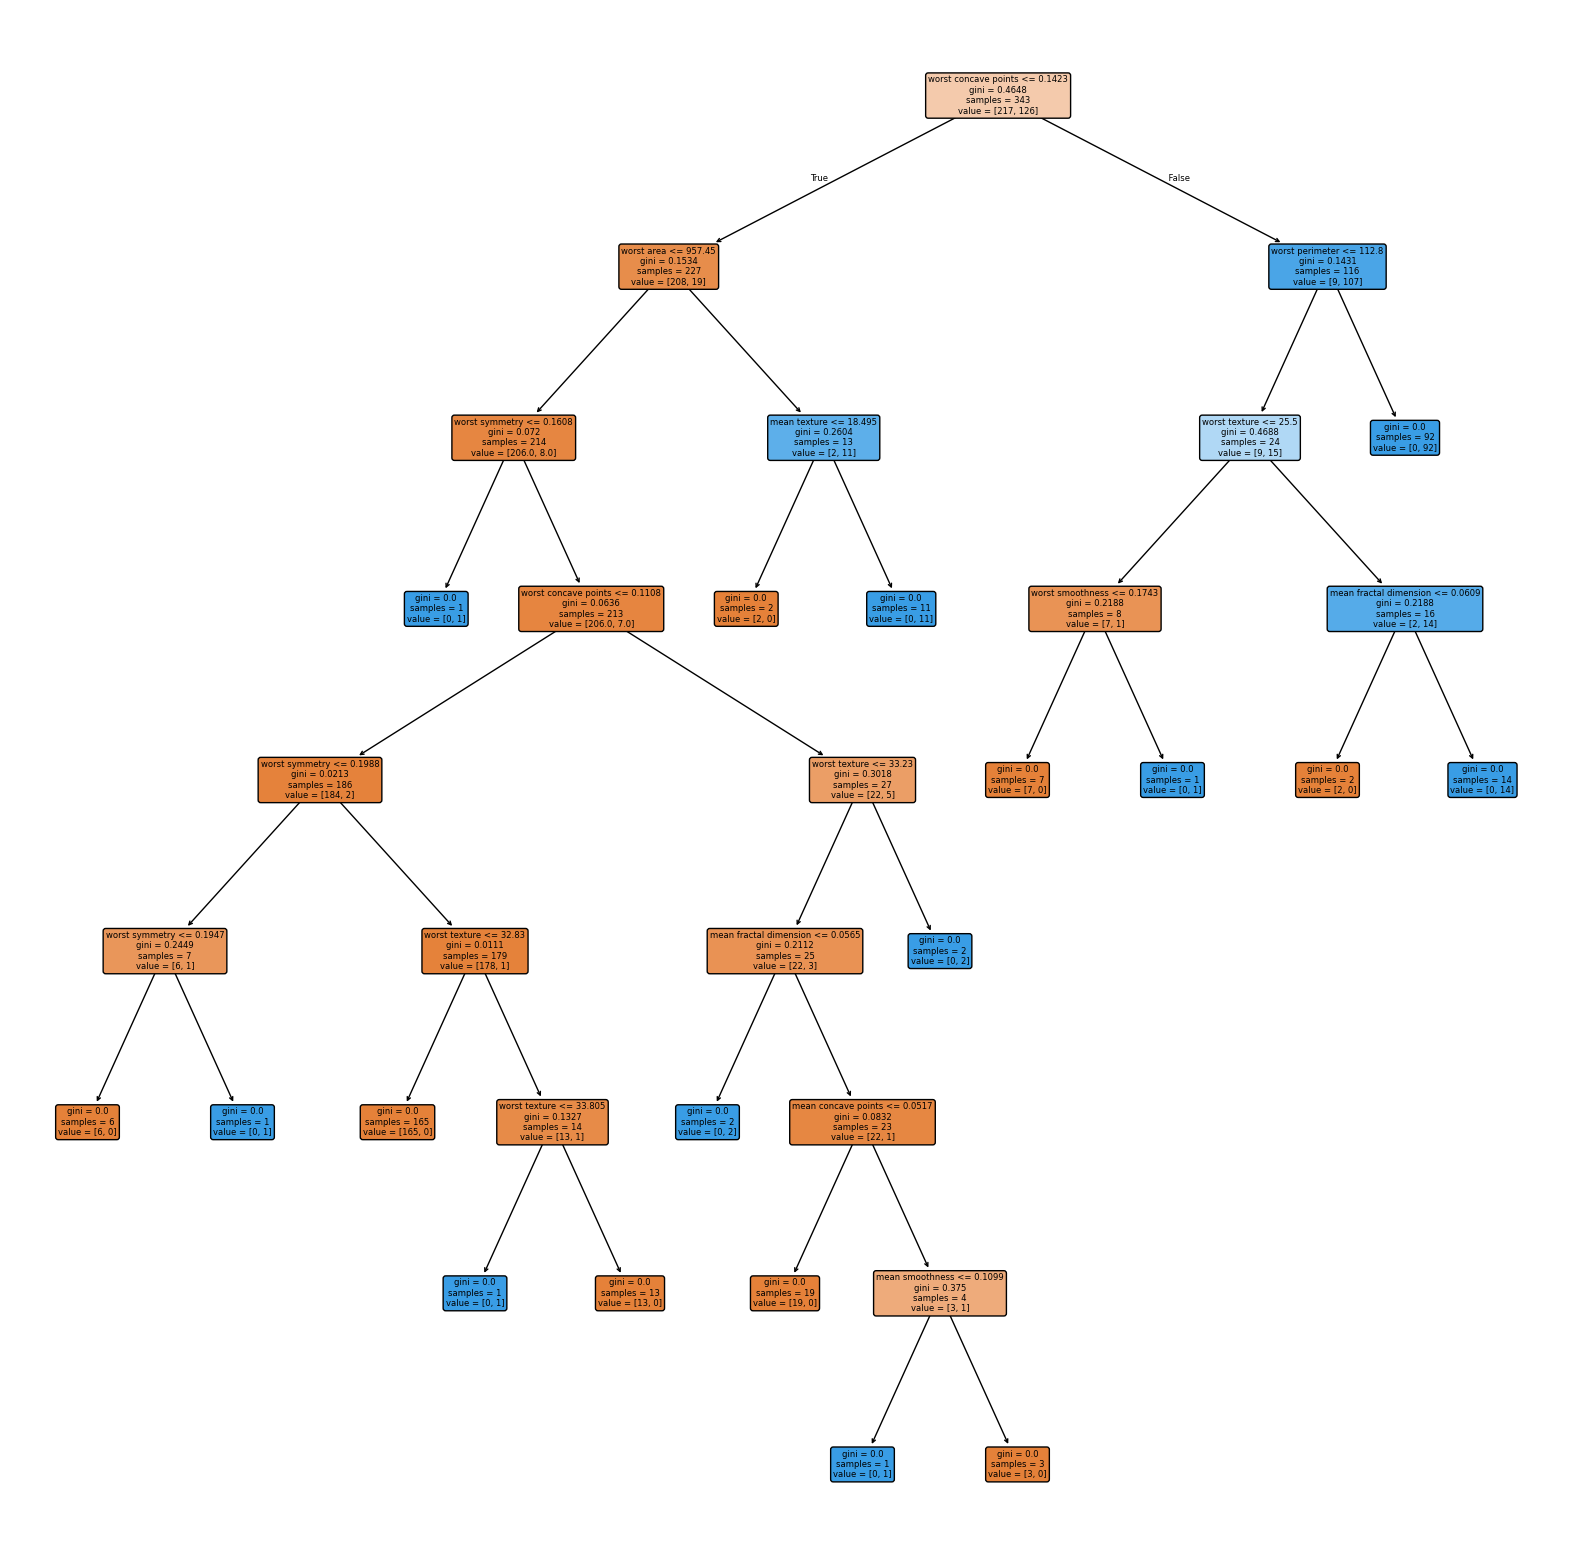

In [75]:
dtree = plt.figure(figsize=(20,20)) # Create a figure 	
plot_tree(model, feature_names=X.columns, filled=True, rounded=True, precision=4) # plot_tree is used to display the trained decision tree. 
# feature_names displays the feature names in the tree nodes.
# filled=True fills the nodes with colors.
# rounded=True rounds the corners of the nodes.
# precision=4 displays up to 4 decimal places.
dtree.savefig('tree.pdf') #Save the tree as a PDF
plt.show()

In [ ]:
from sklearn import metrics 

In [ ]:
y_pred = model.predict(X_valid) # Make predictions on a new dataset to evaluate the model's performance.

To assess the model, we'll use three metrics.

In [78]:
conf_matrix = metrics.confusion_matrix(y_valid, y_pred) #Calculate the confusion matrix by comparing the predictions with the actual observations.
true_neg, false_pos, false_neg, true_pos = conf_matrix.ravel()			
print(conf_matrix)

[[58  8]
 [ 2 45]]


In [79]:
#first metric
specificity = true_neg / (true_neg+false_pos)  
print(specificity)
#The proportion of benign tumors correctly identified is 88%.

0.8787878787878788


In [80]:
#second metric
sensitivity = true_pos /(true_pos+false_neg)
print(sensitivity)
#The proportion of malignant tumors correctly identified is 96%.

0.9574468085106383


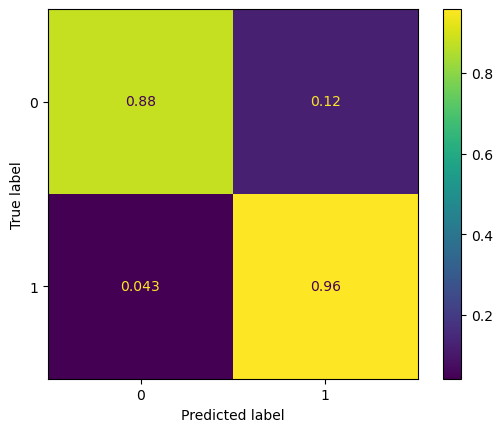

In [81]:
norm_conf_matrix = metrics.confusion_matrix(y_valid,y_pred,normalize='true') # Normalize the values in the confusion matrix
fig = metrics.ConfusionMatrixDisplay(norm_conf_matrix) 
fig.plot() #create the figure			
plt.show() #display the figure


In [82]:
# Third metric
accuracy = metrics.accuracy_score(y_valid, y_pred)
misclassification = 1 - accuracy
print(misclassification)
# The proportion of incorrect predictions is 8.8%.

0.08849557522123896


The metrics indicate that the decision tree performs quite well on new data. However, we can optimize the tree by tuning its hyperparameters. We will focus on the maximum number of leaf nodes and the maximum depth. To do this, we will train different decision trees with different values for these parameters and determine which one performs best on the test data.

In [86]:
misclassification_leaf = {} # Empty dictionary which will contain each misclassification rate along with its max_leaf_node value

for i in range(2,30): 
  # Train a decision tree with a different maximum number of leaf nodes
  tree = DecisionTreeClassifier(max_leaf_nodes=i, random_state = 0)
  tree.fit(X_train,y_train) 

  # Make predictions on the validation set
  pred = tree.predict(X_valid)
  
  # Calculate the misclassification rate
  acc = metrics.accuracy_score(y_valid, pred)
  misclassified = 1 - acc
  misclassification_leaf[i] = misclassified

In [87]:
misclassification_leaf

{2: 0.09734513274336287,
 3: 0.03539823008849563,
 4: 0.03539823008849563,
 5: 0.026548672566371723,
 6: 0.026548672566371723,
 7: 0.03539823008849563,
 8: 0.03539823008849563,
 9: 0.03539823008849563,
 10: 0.03539823008849563,
 11: 0.03539823008849563,
 12: 0.026548672566371723,
 13: 0.026548672566371723,
 14: 0.03539823008849563,
 15: 0.03539823008849563,
 16: 0.03539823008849563,
 17: 0.03539823008849563,
 18: 0.07079646017699115,
 19: 0.07079646017699115,
 20: 0.07079646017699115,
 21: 0.07079646017699115,
 22: 0.07079646017699115,
 23: 0.07079646017699115,
 24: 0.07079646017699115,
 25: 0.07079646017699115,
 26: 0.07079646017699115,
 27: 0.07079646017699115,
 28: 0.07079646017699115,
 29: 0.07079646017699115}

[Text(0.5, 0, 'Max leaf'), Text(0, 0.5, 'Misclassification rate')]

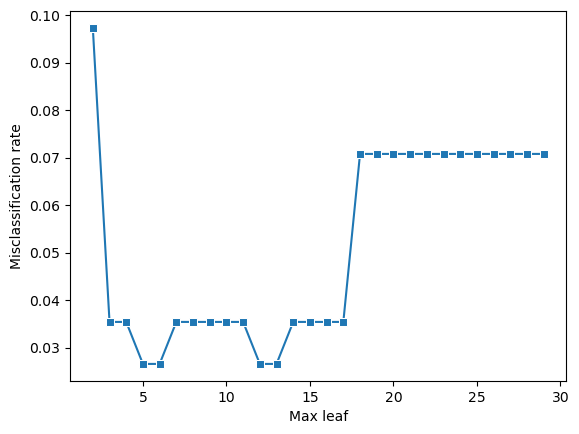

In [88]:
leaf = sns.lineplot(x=misclassification_leaf.keys(), y=misclassification_leaf.values(), marker='s')
leaf.set(xlabel='Max leaf', ylabel='Misclassification rate')

We can see that the misclassification rate is lowest when max_leaf_nodes is approximately 5. We will continue optimizing the model by focusing on the maximum depth of the tree. 

In [ ]:
misclassification_depth = {}

for j in range(1, 6):
  # Train a decision tree with a different maximum depth
  tree = DecisionTreeClassifier(max_depth=j, random_state = 0)
  tree.fit(X_train,y_train)
  
  # Make predictions on the validation set
  pred = tree.predict(X_valid)

  # Calculate the misclassification rate
  acc = metrics.accuracy_score(y_valid, pred)
  misclassified = 1 - acc
  misclassification_depth[j] = misclassified

[Text(0.5, 0, 'Max Depth'), Text(0, 0.5, 'Misclassification rate')]

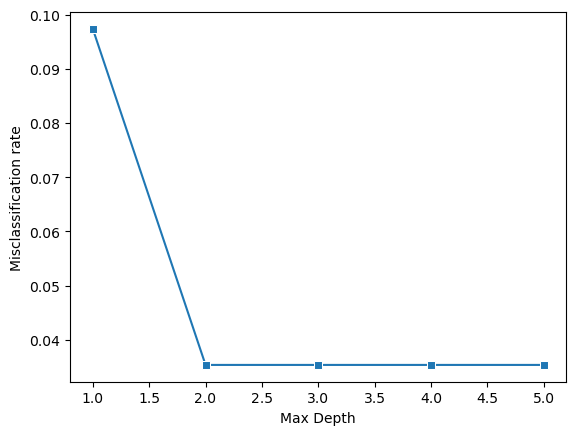

In [90]:
depth = sns.lineplot(x=misclassification_depth.keys(), y=misclassification_depth.values(), marker='s')
depth.set(xlabel='Max Depth', ylabel='Misclassification rate')

Misclassification rate is lowest for max_depth = 2

In [91]:
opti_model = DecisionTreeClassifier(max_depth = 2, max_leaf_nodes = 5, random_state = 0)
opti_model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, 

In [92]:
opti_y_pred = opti_model.predict(X_test)
opti_conf_matrix = metrics.confusion_matrix(y_test, opti_y_pred)
opti_true_neg, opti_false_pos, opti_false_neg, opti_true_pos = opti_conf_matrix.ravel()

[[0.97297297 0.02702703]
 [0.07692308 0.92307692]]


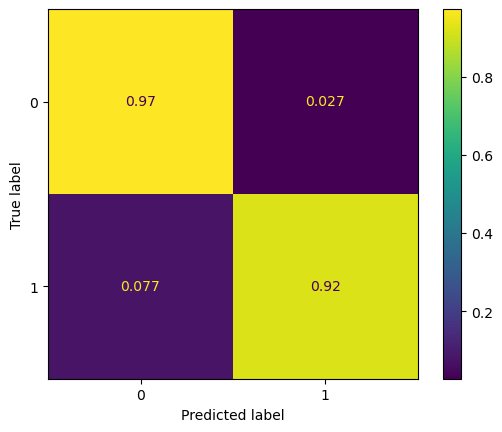

In [93]:
opti_norm_conf_matrix = metrics.confusion_matrix(y_test, opti_y_pred, normalize='true')
opti_fig = metrics.ConfusionMatrixDisplay(opti_norm_conf_matrix)
opti_fig.plot()
print(opti_norm_conf_matrix)
plt.show()

In [94]:
opti_accuracy = metrics.accuracy_score(y_test, opti_y_pred)
print("Optimal Accuracy rate:", opti_accuracy) 
opti_misclassification = 1 - opti_accuracy
print("Optimal Misclassification rate:", opti_misclassification)

Optimal Accuracy rate: 0.9557522123893806
Optimal Misclassification rate: 0.04424778761061943


In [95]:
opti_recall = opti_true_pos / (opti_true_pos + opti_false_neg)
print("Optimal recall:", opti_recall)

Optimal recall: 0.9230769230769231


In [96]:
opti_specificity = opti_true_neg / (opti_true_neg + opti_false_pos)
print("Optimal Specificity:", opti_specificity)

Optimal Specificity: 0.972972972972973


In [114]:
opti_f1score = metrics.f1_score(y_test, opti_y_pred)
print(f"F1 Score : {opti_f1score:.4f}")

F1 Score : 0.9351


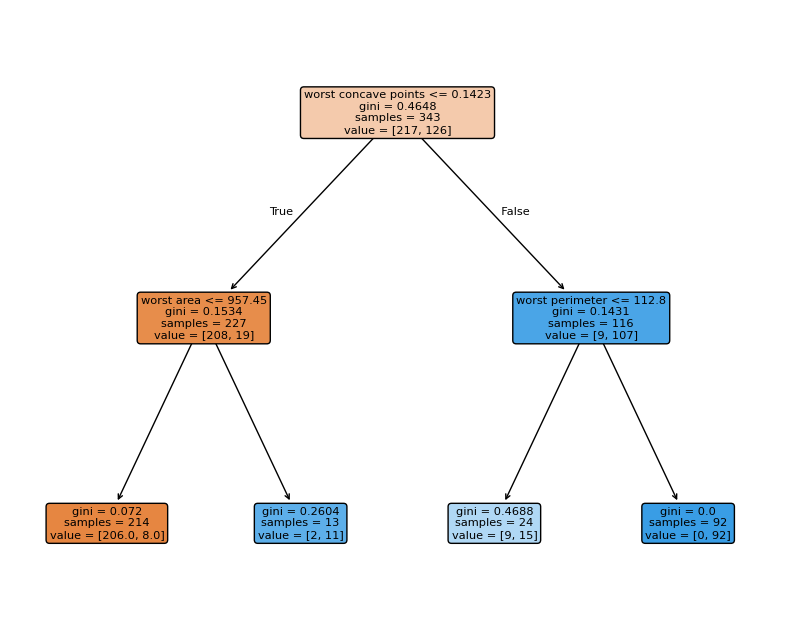

In [98]:
opti_tree = plt.figure(figsize=(10,8))
plot_tree(opti_model, feature_names=X.columns, filled=True, rounded=True, precision=4)
opti_tree.savefig('opti_tree.pdf')
plt.show()

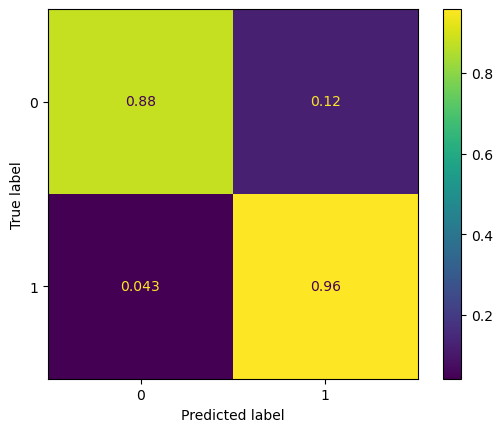

In [99]:
norm_conf_matrix = metrics.confusion_matrix(y_valid,y_pred,normalize='true')  
fig = metrics.ConfusionMatrixDisplay(norm_conf_matrix) 

fig.plot() 			
plt.show() 

We now have a better-performing model with the optimized parameters. However, there are many different hyperparameters, and considering all possible combinations would be too computationally expensive. To address this, we will use GridSearchCV to find the best combination of hyperparameters.

In [100]:
from sklearn.model_selection import GridSearchCV

In [101]:
criterion = ['gini', 'entropy']
# The function used to compute the quality of the split
max_depth = range(1, 10)
max_leaf_nodes = range(2, 20, 2)
min_samples_split = range(2, 20, 2)
# The minimum number of samples to split an internal node
min_samples_leaf = range(1, 50, 5)
# The minimum number of samples to be at a leaf
max_features = ['auto', 'sqrt', 'log2']
# The maximum number of samples to determine the best split

In [102]:
parameters_grid = {
    'criterion': criterion,
    'max_depth': max_depth,
    'max_leaf_nodes': max_leaf_nodes,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,
    'max_features': max_features
}

In [103]:
search = GridSearchCV(model, parameters_grid, scoring='accuracy') # Use GridSearchCV to test different combinations of hyperparameters and select the best one based on accuracy.
search.fit(X_train, y_train) # Train the models on the training data.

c:\Users\Tiago\anaconda3\envs\py313\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
72900 fits failed out of a total of 218700.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
72900 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Tiago\anaconda3\envs\py313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Tiago\anaconda3\envs\py313\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\Tiago\anaconda3\envs\py313\Lib\site-package

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': range(1, 10), 'max_features': ['auto', 'sqrt', ...], 'max_leaf_nodes': range(2, 20, 2), ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time

In [105]:
search_estimator = search.best_estimator_
print(search.best_params_)
print(search_estimator)

{'criterion': 'gini', 'max_depth': 7, 'max_features': 'sqrt', 'max_leaf_nodes': 14, 'min_samples_leaf': 1, 'min_samples_split': 2}
DecisionTreeClassifier(max_depth=7, max_features='sqrt', max_leaf_nodes=14,
                       random_state=0)


In [106]:
search_y_pred = search_estimator.predict(X_test)

Let's see our the performance of this last model

In [107]:
search_conf_matrix = metrics.confusion_matrix(y_test, search_y_pred)
search_true_neg, search_false_pos, search_false_neg, search_true_pos = search_conf_matrix.ravel()

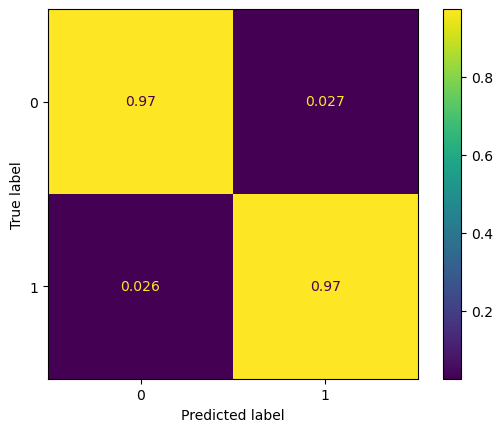

In [109]:
search_norm_conf_matrix = metrics.confusion_matrix(y_test, search_y_pred, normalize='true')
search_fig = metrics.ConfusionMatrixDisplay(search_norm_conf_matrix)
search_fig.plot()

plt.show()

In [110]:
search_accuracy = metrics.accuracy_score(y_test, search_y_pred)
print("Last model Accuracy rate:", search_accuracy) 
search_misclassification = 1 - search_accuracy
print("Last model Misclassification rate:", search_misclassification)

Last model Accuracy rate: 0.9734513274336283
Last model Misclassification rate: 0.026548672566371723


In [111]:
search_recall = search_true_pos / (search_true_pos + search_false_neg)
print("Last model recall:", search_recall)

Last model recall: 0.9743589743589743


In [112]:
search_specificity = search_true_neg / (search_true_neg + search_false_pos)
print("Last model Specificity:", search_specificity)

Last model Specificity: 0.972972972972973


In [113]:
search_f1score = metrics.f1_score(y_test, search_y_pred)
print(f"F1 Score : {search_f1score:.4f}")

F1 Score : 0.9620


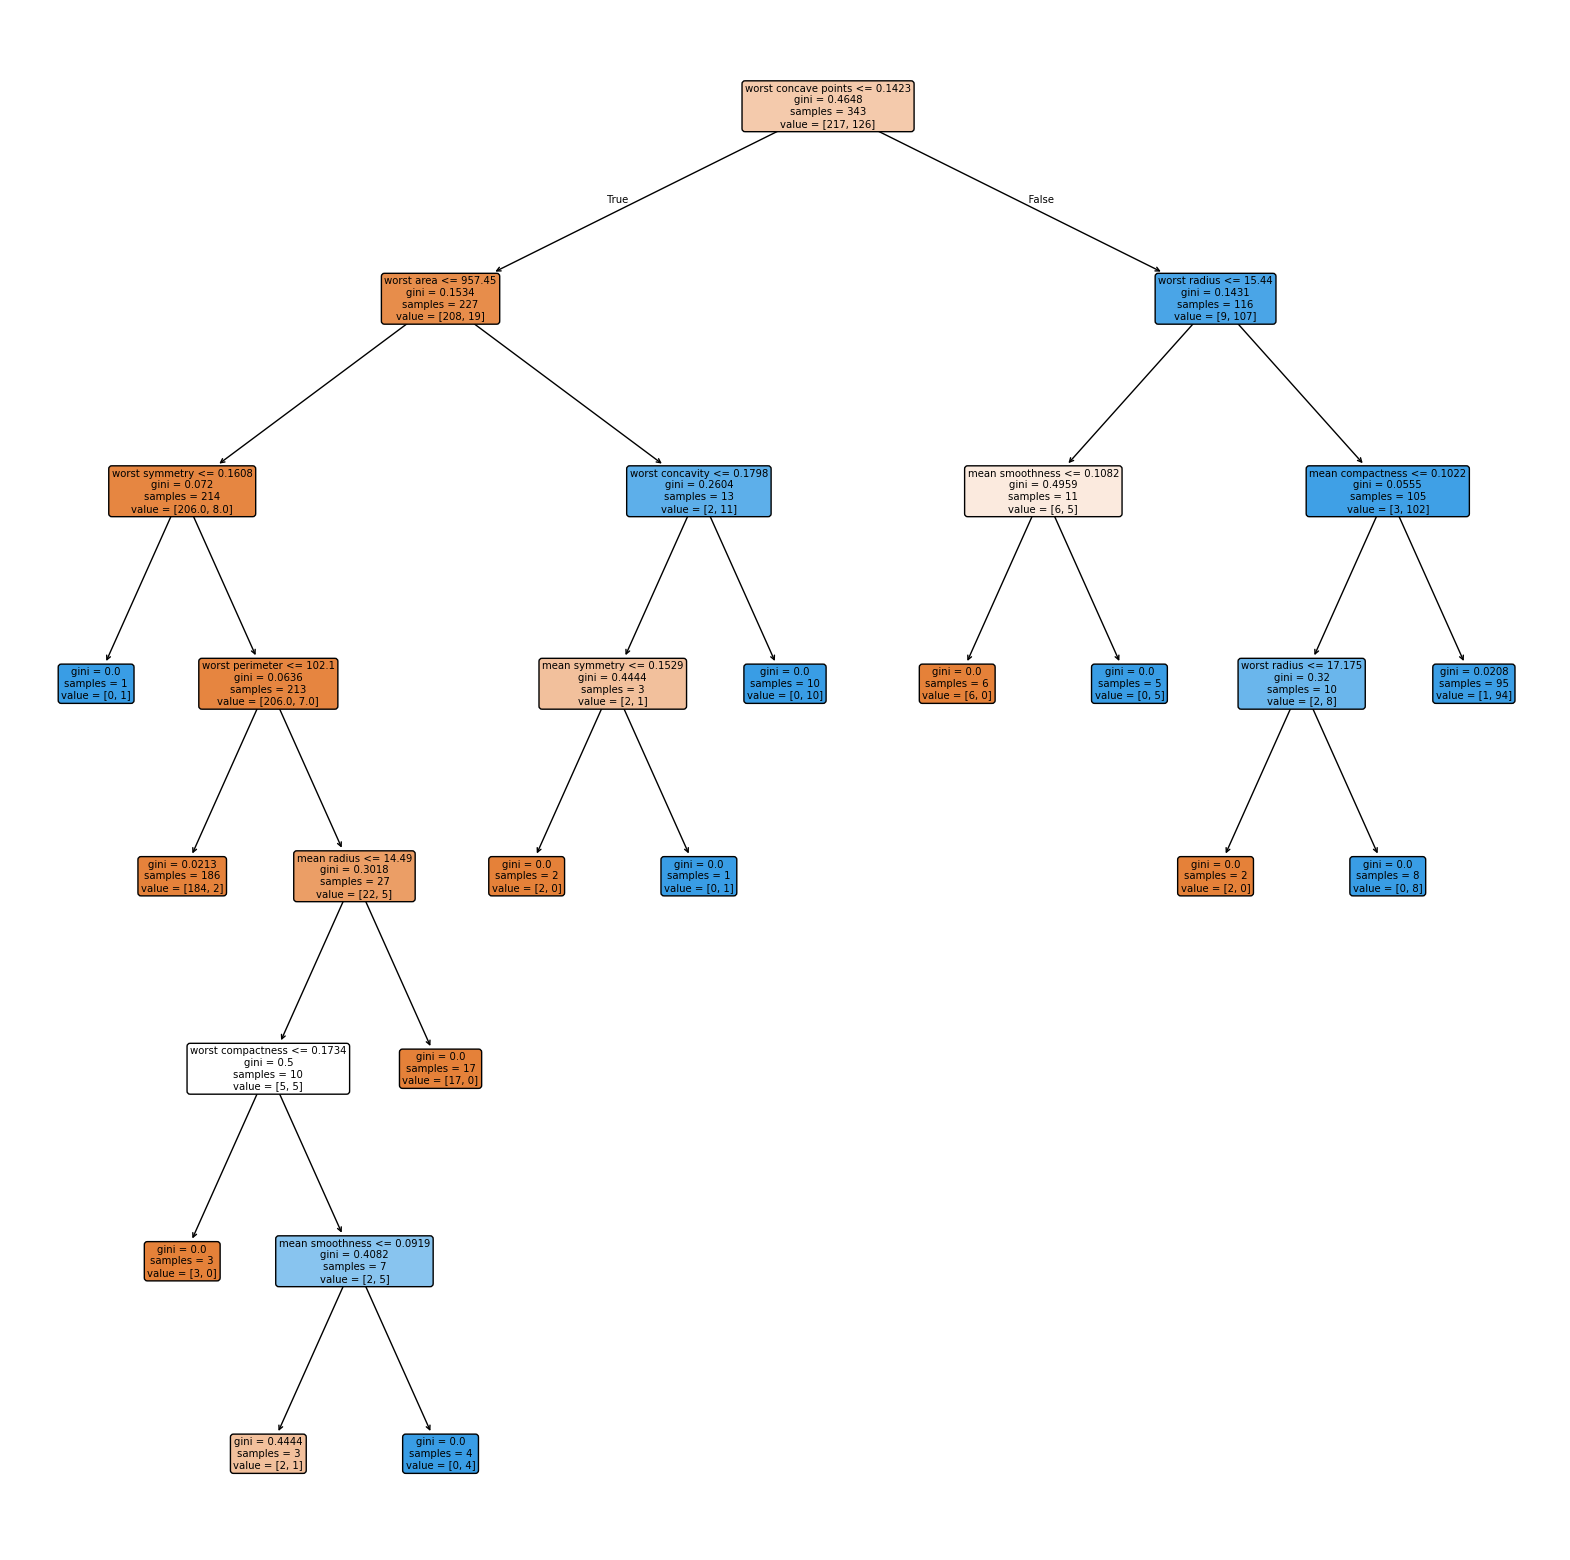

In [120]:
search_tree = plt.figure(figsize=(20,20))
plot_tree(search_estimator, feature_names=X.columns, filled=True, rounded=True, precision=4)
search_tree.savefig('Last_Model_tree.pdf')
plt.show()

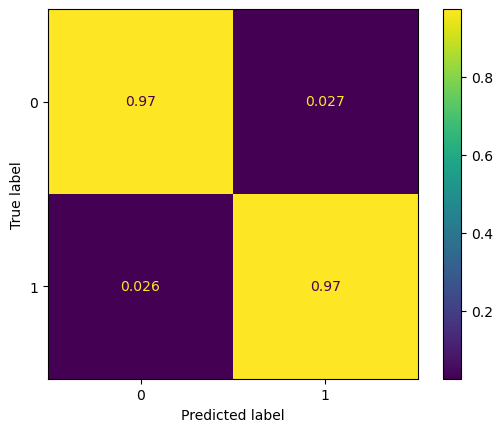

In [123]:
search_norm_conf_matrix = metrics.confusion_matrix(y_test, search_y_pred, normalize='true')
search_fig = metrics.ConfusionMatrixDisplay(search_norm_conf_matrix)
search_fig.plot()

plt.show()